# Joint MCMC Analysis — DIB 15272 / 15672, C2v / Cs
Loads any backend produced by `run_emcee_asym_both.py`, infers all settings
from the filename, redoes the full convergence analysis, makes the corner plot,
and draws 10 posterior-sample profile overlays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
import os.path as osp
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


## 15  PGOPHER Setup
Define spectrum generation functions (mirroring `run_emcee_asym_both.py`).

In [35]:
PGO_BINARY = os.path.expanduser('~/DIB/./pgo')
pgo_available = os.path.isfile(PGO_BINARY)
if not pgo_available:
    print('⚠  pgo binary not found — profile plot cells will be skipped.')

data_wavelength = np.linspace(15272.27178113337 - 6.5, 15272.27178113337+6.5, 2000)
CENTRAL_INVCM_BASE = 1e8 / 15272.27178113337
symmetry = inferred_sym = 'Cs'
PGO_TEMPLATES = {
    ('C2v', '15272'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15272_C2v.pgo'),
    ('Cs',  '15272', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_a.pgo'),
    ('Cs',  '15272', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_b.pgo')
}

TEMP_DIR = tempfile.mkdtemp(prefix='dib_analysis_pgo_')
print(f'PGOPHER temp dir: {TEMP_DIR}')

def _fname_base(T, A, B, C, fA, fB, fC, lorentz=0.01, gaussian = 0.3, axis='b', co=0.0):
    return (f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_'
            f'FA{fA:.5f}_FB{fB:.5f}_FC{fC:.5f}_ax{axis}_lt{lorentz:.3f}_gauss{gaussian:.3f}_off{co:.2f}')

def _run_pgo(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset, template_key):
    """Template-substitute and run pgo; return path to spectrum text file."""
    PGO_TEMPLATE = PGO_TEMPLATES[template_key]
    A_g, B_g, C_g = A, B, C
    A_e, B_e, C_e = A*fA, B*fB, C*fC
    center = CENTRAL_INVCM_BASE + center_offset
    base   = _fname_base(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset)
    pgo_file  = os.path.join(TEMP_DIR, f'tmp_{base}.pgo')
    spec_file = os.path.join(TEMP_DIR, f'spc_{base}.txt')

    # Build awk substitution script
    # The awk structure differs slightly between C2v/15272, C2v/15672, and Cs.
    # We use the same approach as run_emcee_asym_both.py.
    sym = inferred_sym
    dib = inferred_dib

    if sym == 'C2v' and dib == '15272':
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v axis="{axis}" -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}" '
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/ {{ in_ground=1 }}
/<AsymmetricTop Name="v=1"/ {{ in_excited=1 }}
/<\/AsymmetricTop>/ {{ in_ground=0; in_excited=0 }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    else:  # C2v/15672 or any Cs — both use Origin + manifest names
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}" -v center="{center}" '
BEGIN {{ inside_ground=0; inside_excited=0; }}
/<Parameter Name="Temperature" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<AsymmetricManifold Name="Ground"/ {{ inside_ground=1 }}
/<AsymmetricManifold Name="Excited"/ {{ inside_excited=1 }}
/<\/AsymmetricManifold>/ {{ inside_ground=0; inside_excited=0 }}
inside_ground  && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
inside_ground  && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
inside_ground  && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
inside_excited && /<Parameter Name="Origin" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" center "\\"") }}
inside_excited && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
inside_excited && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
inside_excited && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<Parameter Name="Lorentzian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""

    subprocess.run(awk_script, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BINARY, '--plot', pgo_file, spec_file],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return spec_file


def get_pgopher_spectrum(spec_file, center_offset=0.0, dlam=0.01, window=8):
    """Load a PGOPHER spectrum txt and interpolate to data_wavelength grid,
    applying the analytical 3-Gaussian LSF if needed."""
    inv_cm, flux = np.loadtxt(spec_file).T
    wav_pgo = 1e8 / inv_cm

    out_i  = interp1d(wav_pgo, flux, bounds_error=False, fill_value=np.nan)

    return out_i(data_wavelength)


def unpack_params(params):
    """Return (T, A, B, C, fA, fB, fC, lorentz, center_offset) from a flat param vector."""
    if B_not_equal_C:
        if has_center_offset:
            T, A, B, C, fA, fB, fC, lt, sig, co = params
        else:
            T, A, B, C, fA, fB, fC, lt, sig = params; co = 0.0
    else:
        if has_center_offset:
            T, A, C, fA, fC, lt, sig, co = params
        else:
            T, A, C, fA, fC, lt, sig = params; co = 0.0
        if inferred_sym == 'C2v':
            B, fB = A, fA
        else:  # Cs
            B, fB = C, fC
    return T, A, B, C, fA, fB, fC, lt, sig, co


def generate_spectra(params):
    """Run PGOPHER for a param vector; return (model_flux, model_flux_dT) on data_wavelength."""
    T, A, B, C, fA, fB, fC, lt, sig, co = unpack_params(params)
    if inferred_sym == 'C2v':
        tkey = ('C2v', inferred_dib)
        sf      = _run_pgo(T,      A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
        sf_dT   = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
        mf    = get_pgopher_spectrum(sf,    co)
        mf_dT = get_pgopher_spectrum(sf_dT, co)
        return {'C2v': (mf, mf_dT)}
    else:  # Cs — two axes
        results = {}
        for axis in ('a', 'b'):
            tkey  = ('Cs', inferred_dib, axis)
            sf    = _run_pgo(T,      A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
            sf_dT = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
            results[axis] = (get_pgopher_spectrum(sf, co),
                             get_pgopher_spectrum(sf_dT, co))
        return results


def reconstruct_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        spec    = gaussian_filter(mf[c:-c],    gf)
        spec_dT = gaussian_filter(mf_dT[c:-c], gf) - spec

        if rerun_coefficients:
            meas      = data_flux[c:-c]
            meas_dT   = data_flux_dT[c:-c]
            M         = np.vstack([spec, np.ones_like(spec)]).T
            gamma, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
        else:
            gamma, _, offset, alpha_dT, beta_dT, offset_dT = blob_row[:6]

        model_dib = gamma * spec + offset
        model_dT  = alpha_dT * spec + beta_dT * spec_dT + offset_dT
        return model_dib, model_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type
        spec_b    = gaussian_filter(mf_b[c:-c],    gf)
        spec_c    = gaussian_filter(mf_c[c:-c],    gf)
        spec_dT_b = gaussian_filter(mf_dT_b[c:-c], gf) - spec_b
        spec_dT_c = gaussian_filter(mf_dT_c[c:-c], gf) - spec_c

        if rerun_coefficients:
            meas    = data_flux[c:-c]
            meas_dT = data_flux_dT[c:-c]
            M       = np.vstack([spec_b, spec_c, np.ones_like(spec_b)]).T
            b_frac, c_frac, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            ratio   = b_frac / (c_frac + 1e-10)
            base    = spec_b + ratio * spec_c
            delta_b = spec_dT_bp
            delta_c = spec_dT_c
            M_dT    = np.vstack([base, delta_b + ratio * delta_c, np.ones_like(base)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
            base_frac_dT = 0.0
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = alpha_dT * base + beta_dT * (delta_b + ratio * delta_c) + offset_dT
        elif n_blobs == 7:  # use_scalar_prior=True path
            b_frac, c_frac, offset, base_frac_dT, b_frac_dT, c_frac_dT, offset_dT = blob_row[:7]
            ratio     = b_frac / (c_frac + 1e-10)
            base      = spec_b + ratio * spec_c
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = (base_frac_dT * base +
                         b_frac_dT * spec_dT_b + c_frac_dT * spec_dT_c + offset_dT)
        else:  # 6-blob nonlinear path
            gamma, ratio_bc, offset_spec, alpha_dT, beta_dT, offset_dT = blob_row[:6]
            base      = spec_b + ratio_bc * spec_c
            delta     = spec_dT_b + ratio_bc * spec_dT_c
            model_dib = gamma * base + offset_spec
            model_dT  = alpha_dT * base + beta_dT * delta + offset_dT

        return model_dib, model_dT, 
    
def return_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        return mf, mf_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type

        return (mf_b, mf_c), (mf_dT_b, mf_dT_c)

print('PGOPHER helper functions defined.')
print(f'pgo binary: {"found" if pgo_available else "NOT FOUND — profile plot will be skipped"}')

PGOPHER temp dir: /tmp/dib_analysis_pgo_yxna0agv
PGOPHER helper functions defined.
pgo binary: found


## 16  Draw Posterior Samples & Generate Model Spectra

In [36]:
models_dib = []
models_dT  = []
T, A, B, C, fA, fB, fC, lt, sig = [10, 0.01, 0.001, 0.001, 0.99, 0.99, 0.99, 0.1, 0.1]
ratio_bc, alpha_dT = 1, 1
B_not_equal_C = True
has_center_offset = True
inferred_dib = '15272'
inferred_sym = 'Cs'
c_crop, gf_sigma = 1, 0
rerun_coefficients = False

params     = [T, A, B, C, fA, fB, fC, lt, sig, 0] #offset always zero
blob_row   = [1, ratio_bc, 0, alpha_dT, 1, 0]
n_blobs = len(blob_row) 

try:
    spectra    = generate_spectra(params)
    mdib, mdT  = return_model(spectra, blob_row)
    print(mdib, mdT)
    models_dib.append(mdib)
    models_dT.append(mdT)
except Exception as e:
    print(f'FAILED: {e}')
    models_dib.append(None)
    models_dT.append(None)

models_dib = [m for m in models_dib if m is not None]
models_dT  = [m for m in models_dT  if m is not None]
models_dib[0]

(array([           nan,            nan,            nan, ...,
       7.90937311e-13, 7.50450511e-13, 7.15114400e-13]), array([           nan,            nan,            nan, ...,
       5.35450613e-06, 5.25177365e-06, 5.16892918e-06])) (array([           nan,            nan,            nan, ...,
       8.66827171e-13, 8.22646325e-13, 7.84083698e-13]), array([           nan,            nan,            nan, ...,
       5.52833803e-06, 5.42275065e-06, 5.33748210e-06]))


(array([           nan,            nan,            nan, ...,
        7.90937311e-13, 7.50450511e-13, 7.15114400e-13]),
 array([           nan,            nan,            nan, ...,
        5.35450613e-06, 5.25177365e-06, 5.16892918e-06]))

In [32]:
idx = 1
mask = np.isnan(models_dib[0])[idx]
val = np.trapz(np.array(models_dib[0])[idx][~mask], data_wavelength[~mask])
val, val*np.sqrt(2)

(0.7266293442599463, 1.0276090734706849)

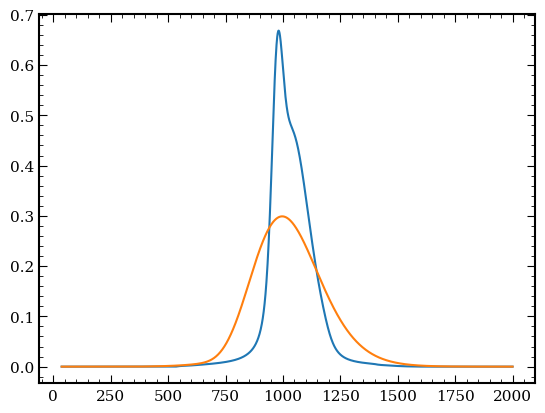

In [30]:
plt.plot(mdib[0])
plt.plot(mdib[1])

In [52]:
models_dib = []
models_dT  = []
T, A, B, C, fA, fB, fC, lt, sig = [20, 0.08, 0.01, 0.001, 0.99, 0.99, 0.99, 0.01, 0.01]
ratio_bc, alpha_dT = 1, 1
B_not_equal_C = True
has_center_offset = True
inferred_dib = '15272'
inferred_sym = 'C2v'
c_crop, gf_sigma = 1, 0
rerun_coefficients = False

params     = [T, A, B, C, fA, fB, fC, lt, sig, 0] #offset always zero
blob_row   = [1, ratio_bc, 0, alpha_dT, 1, 0]
n_blobs = len(blob_row) 

try:
    spectra    = generate_spectra(params)
    mdib, mdT  = return_model(spectra, blob_row)
    print(mdib, mdT)
    models_dib.append(mdib)
    models_dT.append(mdT)
except Exception as e:
    print(f'FAILED: {e}')
    models_dib.append(None)
    models_dT.append(None)

models_dib = [m for m in models_dib if m is not None]
models_dT  = [m for m in models_dT  if m is not None]
models_dib

[0.00053804 0.00053611 0.00053401 ... 0.00043416 0.00039574 0.00038381] [0.00053822 0.00053618 0.00053398 ... 0.00043508 0.00039656 0.0003845 ]


[array([0.00053804, 0.00053611, 0.00053401, ..., 0.00043416, 0.00039574,
        0.00038381])]

In [56]:
idx = 0
dl = data_wavelength[1] - data_wavelength[0]
mask = np.isnan(models_dib[0])
val = np.trapz(np.array(models_dib[0])[~mask], data_wavelength[~mask])
val, val*np.sqrt(2), np.sum(np.array(models_dib[0])[~mask]*dl)

(0.6482465899092733, 0.9167591192118043, 0.6482495873159593)

save JSON in the right format

In [5]:
"""
Generate a grid of PGOPHER spectra and export JSON for the spectrum_viewer widget.

Usage:
  1. Set the grid values below to taste.
  2. Run this script (needs pgo binary, templates, numpy, scipy).
  3. Output: static/data/mol_spectra.json

Grid count with defaults below:
  4 T × 1 A × 4 b_fac × 4 c_fac × 3 fA × 3 fB × 3 fC × 3 lt × 2 sig = 15,552 param combos
  For Cs each combo → 4 PGO calls (2 axes × {T, T+dT}).
"""

import os, json, tempfile, subprocess
import numpy as np
from scipy.interpolate import interp1d

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION  — edit these
# ═══════════════════════════════════════════════════════════════════════════
PGO_BINARY = os.path.expanduser('~/DIB/./pgo')
pgo_available = os.path.isfile(PGO_BINARY)
if not pgo_available:
    raise RuntimeError('pgo binary not found at ' + PGO_BINARY)

inferred_sym = 'Cs'        # 'C2v' or 'Cs'
inferred_dib = '15272'

# Wavelength grid (Angstroms) — shared x-axis for all spectra
CENTER_WAV = 15272.27178113337
data_wavelength = np.linspace(CENTER_WAV - 6.5, CENTER_WAV + 6.5, 2000)
CENTRAL_INVCM_BASE = 1e8 / CENTER_WAV

PGO_TEMPLATES = {
    ('C2v', '15272'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15272_C2v.pgo'),
    ('Cs',  '15272', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_a.pgo'),
    ('Cs',  '15272', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_b.pgo'),
}

TEMP_DIR = tempfile.mkdtemp(prefix='dib_grid_pgo_')
print(f'PGOPHER temp dir: {TEMP_DIR}')

# Output paths (relative to Hugo site root)

ext = 'Cs_small'

OUTPUT_DIR   = os.path.expanduser('~/DIB/demo_data/')
OUTPUT_INDEX = os.path.join(OUTPUT_DIR, f'mol_spectra_index_{ext}.json')
OUTPUT_BIN   = os.path.join(OUTPUT_DIR, f'mol_spectra_data_{ext}.bin')

# # ── Parameter grid ────────────────────────────────────────────────────────
# GRID_T     = [5, 10, 20, 40]
# GRID_A     = [0.04]
# GRID_b_fac = [0.98, 0.5, 0.1]   # B = A × b_fac
# GRID_c_fac = [0.98, 0.5, 0.1]   # C = B × c_fac
# GRID_fA    = [1.0, 0.98, 0.92]
# GRID_fB    = [1.0, 0.98, 0.92]
# GRID_fC    = [1.0, 0.98, 0.92]
# GRID_lt    = [0.01, 0.3]          # Lorentz width (cm⁻¹)
# GRID_sig   = [0.01, 0.3]               # Gaussian width (cm⁻¹)

# ── Parameter grid ────────────────────────────────────────────────────────
GRID_T     = [5, 40]
GRID_A     = [0.04]
GRID_b_fac = [0.98, 0.1]   # B = A × b_fac
GRID_c_fac = [0.98, 0.1]   # C = B × c_fac
GRID_fA    = [1.0, 0.92]
GRID_fB    = [1.0, 0.92]
GRID_fC    = [1.0, 0.92]
GRID_lt    = [0.01, 0.3]          # Lorentz width (cm⁻¹)
GRID_sig   = [0.01, 0.3]               # Gaussian width (cm⁻¹)

# dT step for finite-difference derivative
DT_STEP = 0.05  # K

# ═══════════════════════════════════════════════════════════════════════════
# PGOPHER HELPERS  (unchanged from your code)
# ═══════════════════════════════════════════════════════════════════════════
def _fname_base(T, A, B, C, fA, fB, fC, lorentz=0.01, gaussian=0.3, axis='b', co=0.0):
    return (f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_'
            f'FA{fA:.5f}_FB{fB:.5f}_FC{fC:.5f}_ax{axis}_lt{lorentz:.3f}_gauss{gaussian:.3f}_off{co:.2f}')


def _run_pgo(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset, template_key):
    """Template-substitute and run pgo; return path to spectrum text file."""
    PGO_TEMPLATE = PGO_TEMPLATES[template_key]
    A_g, B_g, C_g = A, B, C
    A_e, B_e, C_e = A * fA, B * fB, C * fC
    center = CENTRAL_INVCM_BASE + center_offset
    base = _fname_base(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset)
    pgo_file  = os.path.join(TEMP_DIR, f'tmp_{base}.pgo')
    spec_file = os.path.join(TEMP_DIR, f'spc_{base}.txt')

    sym = inferred_sym
    dib = inferred_dib

    if sym == 'C2v' and dib == '15272':
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v axis="{axis}" -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}" '
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/ {{ in_ground=1 }}
/<AsymmetricTop Name="v=1"/ {{ in_excited=1 }}
/<\\/AsymmetricTop>/ {{ in_ground=0; in_excited=0 }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    else:
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}" -v center="{center}" '
BEGIN {{ inside_ground=0; inside_excited=0; }}
/<Parameter Name="Temperature" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<AsymmetricManifold Name="Ground"/ {{ inside_ground=1 }}
/<AsymmetricManifold Name="Excited"/ {{ inside_excited=1 }}
/<\\/AsymmetricManifold>/ {{ inside_ground=0; inside_excited=0 }}
inside_ground  && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
inside_ground  && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
inside_ground  && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
inside_excited && /<Parameter Name="Origin" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" center "\\"") }}
inside_excited && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
inside_excited && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
inside_excited && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<Parameter Name="Lorentzian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    subprocess.run(awk_script, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BINARY, '--plot', pgo_file, spec_file],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return spec_file


def get_pgopher_spectrum(spec_file):
    """Load a PGOPHER spectrum txt and interpolate to data_wavelength grid."""
    inv_cm, flux = np.loadtxt(spec_file).T
    wav_pgo = 1e8 / inv_cm
    out_i = interp1d(wav_pgo, flux, bounds_error=False, fill_value=np.nan)
    return out_i(data_wavelength)


# ═══════════════════════════════════════════════════════════════════════════
# GRID GENERATION
# ═══════════════════════════════════════════════════════════════════════════
from itertools import product

grid_axes = [GRID_T, GRID_A, GRID_b_fac, GRID_c_fac,
             GRID_fA, GRID_fB, GRID_fC, GRID_lt, GRID_sig]
total = 1
for g in grid_axes:
    total *= len(g)
print(f'Total grid points: {total}')

spectra_list = []
n_ok, n_fail = 0, 0

for idx, (T, A, b_fac, c_fac, fA, fB, fC, lt, sig) in enumerate(product(*grid_axes)):
    B = A * b_fac
    C = B * c_fac
    co = 0.0  # center offset always zero for the grid


    print(f'  [{idx+1}/{total}]  T={T}  A={A}  B={B:.6f}  C={C:.6f}  '
          f'fA={fA}  fB={fB}  fC={fC}  lt={lt}  sig={sig}')

    try:
        if inferred_sym == 'C2v':
            tkey = ('C2v', inferred_dib)
            sf    = _run_pgo(T,           A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
            sf_dT = _run_pgo(T + DT_STEP, A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
            mf    = get_pgopher_spectrum(sf)
            mf_dT = get_pgopher_spectrum(sf_dT)

            # dT = finite-difference derivative spectrum
            entry = {
                'params': {
                    'T': T, 'A': A, 'B': B, 'C': C,
                    'fA': fA, 'fB': fB, 'fC': fC,
                    'tau': lt, 'sigma': sig,
                },
                'intensity_b':    mf.tolist(),
                'dT_intensity_b': (mf_dT - mf).tolist(),
            }

        else:  # Cs — two axes
            entry_data = {}
            for axis, key_suffix in [('a', 'b'), ('b', 'c')]:
                # a-axis pgo → b-type spectrum, b-axis pgo → c-type spectrum
                tkey  = ('Cs', inferred_dib, axis)
                sf    = _run_pgo(T,           A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
                sf_dT = _run_pgo(T + DT_STEP, A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
                mf    = get_pgopher_spectrum(sf)
                mf_dT = get_pgopher_spectrum(sf_dT)
                entry_data[f'intensity_{key_suffix}']    = mf.tolist()
                entry_data[f'dT_intensity_{key_suffix}'] = (mf_dT - mf).tolist()

            entry = {
                'params': {
                    'T': T, 'A': A, 'B': B, 'C': C,
                    'fA': fA, 'fB': fB, 'fC': fC,
                    'tau': lt, 'sigma': sig,
                },
                **entry_data,
            }

        spectra_list.append(entry)
        n_ok += 1

    except Exception as e:
        n_fail += 1
        print(f'  [{idx+1}/{total}]  FAILED: {e}')

print(f'\nDone: {n_ok} succeeded, {n_fail} failed out of {total}')

# ═══════════════════════════════════════════════════════════════════════════
# EXPORT — BINARY (.bin) + INDEX (.json)
# ═══════════════════════════════════════════════════════════════════════════
#
# Binary layout (all Float32, little-endian):
#   [wavelength: N floats] [spectrum_0: 4×N floats] [spectrum_1: 4×N floats] …
#
# Per-spectrum block order:
#   intensity_b | intensity_c | dT_intensity_b | dT_intensity_c
#
# Index JSON:
#   { "n_wav": N, "n_spectra": M, "spectra": [ {params dict}, … ] }
#
import struct

N_WAV = len(data_wavelength)
ARRAYS_PER_SPECTRUM = 4
ARRAY_KEYS = ['intensity_b', 'intensity_c', 'dT_intensity_b', 'dT_intensity_c']

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(OUTPUT_BIN, 'wb') as bf:
    # 1. Write wavelength array
    bf.write(np.array(data_wavelength, dtype=np.float32).tobytes())

    # 2. Write each spectrum's 4 arrays
    index_params = []
    for entry in spectra_list:
        index_params.append(entry['params'])
        for key in ARRAY_KEYS:
            arr = entry.get(key)
            if arr is not None:
                bf.write(np.array(arr, dtype=np.float32).tobytes())
            else:
                # Missing array (e.g. C2v has no intensity_c) → write zeros
                bf.write(np.zeros(N_WAV, dtype=np.float32).tobytes())

# 3. Write index JSON (small — just params, no spectra data)
index = {
    'n_wav':     N_WAV,
    'n_spectra': len(spectra_list),
    'spectra':   index_params,
}

with open(OUTPUT_INDEX, 'w') as f:
    json.dump(index, f)

bin_mb = os.path.getsize(OUTPUT_BIN) / 1e6
idx_kb = os.path.getsize(OUTPUT_INDEX) / 1e3
print(f'\nWrote {OUTPUT_BIN}  ({bin_mb:.1f} MB)')
print(f'Wrote {OUTPUT_INDEX}  ({idx_kb:.0f} KB)')
print(f'{len(spectra_list)} spectra × {N_WAV} wavelengths × 4 arrays')
print(f'Tip: gzip the .bin before deploying — '
      f'expected transfer size ~{bin_mb * 0.25:.0f} MB')

PGOPHER temp dir: /tmp/dib_grid_pgo_zospt98k
Total grid points: 256
  [1/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=1.0  lt=0.01  sig=0.01
  [2/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=1.0  lt=0.01  sig=0.3
  [3/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=1.0  lt=0.3  sig=0.01
  [4/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=1.0  lt=0.3  sig=0.3
  [5/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=0.92  lt=0.01  sig=0.01
  [6/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=0.92  lt=0.01  sig=0.3
  [7/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=0.92  lt=0.3  sig=0.01
  [8/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=1.0  fC=0.92  lt=0.3  sig=0.3
  [9/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=0.92  fC=1.0  lt=0.01  sig=0.01
  [10/256]  T=5  A=0.04  B=0.039200  C=0.038416  fA=1.0  fB=0.92  fC=1.0  lt=0.01  sig=0.3
  [11/256]  T=5  A=0.04  B=0.03920

  [90/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.01  sig=0.3
  [91/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.3  sig=0.01
  [92/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.3  sig=0.3
  [93/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=0.92  lt=0.01  sig=0.01
  [94/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=0.92  lt=0.01  sig=0.3
  [95/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=0.92  lt=0.3  sig=0.01
  [96/256]  T=5  A=0.04  B=0.004000  C=0.003920  fA=0.92  fB=0.92  fC=0.92  lt=0.3  sig=0.3
  [97/256]  T=5  A=0.04  B=0.004000  C=0.000400  fA=1.0  fB=1.0  fC=1.0  lt=0.01  sig=0.01
  [98/256]  T=5  A=0.04  B=0.004000  C=0.000400  fA=1.0  fB=1.0  fC=1.0  lt=0.01  sig=0.3
  [99/256]  T=5  A=0.04  B=0.004000  C=0.000400  fA=1.0  fB=1.0  fC=1.0  lt=0.3  sig=0.01
  [100/256]  T=5  A=0.04  B=0.004000  C=0.000400  fA=1.0  fB=1.0  fC=1.0  lt=0.3  

  [179/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=1.0  lt=0.3  sig=0.01
  [180/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=1.0  lt=0.3  sig=0.3
  [181/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=0.92  lt=0.01  sig=0.01
  [182/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=0.92  lt=0.01  sig=0.3
  [183/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=0.92  lt=0.3  sig=0.01
  [184/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=1.0  fC=0.92  lt=0.3  sig=0.3
  [185/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.01  sig=0.01
  [186/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.01  sig=0.3
  [187/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.3  sig=0.01
  [188/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=0.92  fC=1.0  lt=0.3  sig=0.3
  [189/256]  T=40  A=0.04  B=0.039200  C=0.003920  fA=0.92  fB=